# 챗봇에서 도구 사용하기

In [1]:
from dotenv import load_dotenv

load_dotenv()

OPENAI_LLM_MODEL = 'gpt-4.1-mini'

## 도구 Tool 정의

In [2]:
from langchain_tavily import TavilySearch 

tavily_tool = TavilySearch(max_results=2)

# 도구 정상 동작 단독 확인
tavily_tool.invoke('LangGraph에서 노드는 무엇인가요?')

{'query': 'LangGraph에서 노드는 무엇인가요?',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://tilnote.io/books/68156a4ebaa37b745385c23b/68156a79baa37b745385c298',
   'title': '3장: LangGraph의 핵심 구성요소 – 노드, 엣지, 상태 관리 - LangGraph 활용 가이드',
   'content': '3장: LangGraph의 핵심 구성요소 – 노드, 엣지, 상태 관리. ## LangGraph 핵심 컴포넌트 이해하기. LangGraph를 본격적으로 활용하려면 가장 먼저 세 가지 개념인 노드, 엣지, 그리고 상태 관리의 원리를 뚜렷하게 파악해야 한다. 이 장에서는 각각의 요소가 어떻게 맞물려 그래프 워크플로우를 구성하는지, 실제 개발 관점에서는 어떤 식으로 조합해야 하는지 자세히 다룬다. ## 노드: 독립 작업 단위의 정의. 노드는 LangGraph 워크플로우에서 하나하나의 작업 구간을 가리킨다. 각 노드는 입력으로 현재 상태 정보를 받고, 자신만의 작업 뒤에 업데이트된 상태를 돌려준다. ## 엣지: 흐름과 분기점 설계. 엣지는 단순하게 다음 작업 노드를 가리킬 수도 있고, 조건에 따라 서로 다른 경로를 지정할 수도 있다. 예를 들어 특정 분석 결과에 따라 다른 처리 로직으로 이동하게끔 조건부 분기를 만들 수 있다. 반복 구조나 순환 경로 또한 엣지 설계만으로 충분히 표현할 수 있다. LangGraph에서는 문맥과 작업 중간 결과 모두를 하나의 상태 객체에서 다룬다. 각 노드가 상태 객체에 자신의 결과나 작업 로그를 누적하는 식으로 설계하면, 전체 프로세스의 가시성과 확장성이 크게 높아진다. LangGraph의 진가는 상태, 노드, 엣지 세 요소의 치밀한 조합에서 드러난다.',
   'score': 0.99997187,
   'raw_content': Non

## LLM에 도구 바인딩 하기

In [3]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model=OPENAI_LLM_MODEL)

tools = [tavily_tool]

# llm에게 사용 가능한 도구 목록을 알려준다.
llm_with_tools = llm.bind_tools(tools)

print(type(llm))
print(type(llm_with_tools))

<class 'langchain_openai.chat_models.base.ChatOpenAI'>
<class 'langchain_core.language_models.chat_models._ChatModelBinding'>


## 그래프 구성

### State 정의

In [4]:
from typing import Annotated, TypedDict
from langchain_core.messages import AnyMessage
from langgraph.graph.message import add_messages

class State(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]

### Chatbot Node 정의

In [5]:
def chatbot(state: State) -> State:
    response = llm_with_tools.invoke(state['messages'])
    return {'messages' : [response]}

### ToolNode 정의

In [6]:
import json
from langchain_core.messages import ToolMessage

class SimpleToolNode:

    def __init__(self, tools):
        # 도구 이름으로 실제 도구 객체를 찾을 수 있도록 딕셔너리로 변환
        self.tools_by_name = {tool.name: tool for tool in tools}

    def __call__(self, inputs: State) -> State:
        # LangGraph가 이 노드를 호출할 때 현재 state를 inputs로 전달한다.
        messages = inputs.get('messages', [])
        if not messages:
            raise ValueError('No message found in inputs')
        
        ai_message = messages[-1]

        outputs = []

        for tool_call in ai_message.tool_calls:
            tool_name = tool_call['name']
            tool_args = tool_call['args']

            # 모델이 요청한 이름의 도구를 찾아 실행한다.
            tool_result = self.tools_by_name[tool_name].invoke(tool_args)

            # 도구 실행 결과는 ToolMessage로 감싸서 messages에 추가해야 한다.
            tool_message = ToolMessage(
                content=json.dumps(tool_result, ensure_ascii=False),
                name=tool_name,
                tool_call_id=tool_call['id']
            )
            outputs.append(tool_message)

        return {'messages' : outputs}
    
simple_tool_node = SimpleToolNode(tools)

### 조건부 Edge 정의

In [ ]:
from langgraph.graph import END

def route_tools(state: State):
    messages = state.get('messages', [])
    if not messages:
        raise ValueError('No messages fount in input state')
    
    ai_message = messages[-1]

    # tool_calls가 있으면 tools 노드로 이동한다.
    has_tool_calls = bool(getattr(ai_message, 'tool_calls', None))
    print(f'last message has tool calls? = {has_tool_calls}')

    if has_tool_calls:
        return 'tools'
    
    return END

### 노드와 엣지 연결 후 컴파일

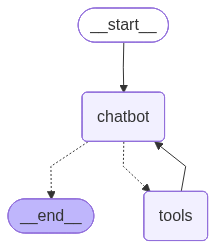

In [8]:
from langgraph.graph import START, StateGraph

workflow = StateGraph(State)

# 각 노드를 그래프에 등록한다.
workflow.add_node("chatbot", chatbot)
workflow.add_node("tools", simple_tool_node)

# 그래프 시작 지점은 chatbot 노드이다.
workflow.add_edge(START, "chatbot")

# 도구 실행 결과를 LLM이 다시 읽고 최종 답변을 만들 수 있도록 chatbot으로 되돌린다.
workflow.add_edge("tools", "chatbot")

# chatbot의 결과에 tool_calls가 있으면 tools로 없으면 END로 이동한다.
workflow.add_conditional_edges(
    'chatbot',
    route_tools,
    {'tools': 'tools', END : END}
)

graph = workflow.compile()
graph

## 그래프 실행

In [9]:
from langchain_core.messages import HumanMessage

# 검색 도구를 사용할 가능성이 높은 질문
user_input = '오늘 기준 LangGraph에서 ToolNode가 어떤 역할을 하는지 검색해서 설명해줘.'
initial_state = {'messages' : [HumanMessage(content=user_input)]}

final_state = graph.invoke(initial_state)
final_state

last message has too calls? = True
last message has too calls? = False


{'messages': [HumanMessage(content='오늘 기준 LangGraph에서 ToolNode가 어떤 역할을 하는지 검색해서 설명해줘.', additional_kwargs={}, response_metadata={}, id='b2513b83-b6b1-4bbb-8536-081f7633c67b'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 29, 'prompt_tokens': 1206, 'total_tokens': 1235, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4.1-mini-2025-04-14', 'system_fingerprint': 'fp_1382f6fe5a', 'id': 'chatcmpl-DggS9eGCjOlxTpOWTThDZ7DEFJiuV', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019e388e-b07c-7503-811d-4f2c84004a38-0', tool_calls=[{'name': 'tavily_search', 'args': {'query': 'LangGraph ToolNode 역할', 'time_range': 'day', 'topic': 'general'}, 'id': 'call_4nz9nzjyTlyFb5Oiu8ZwvPZE', 'typ

In [11]:
from IPython.display import Markdown
# 최종 답변만 확인
Markdown(final_state['messages'][-1].content)

오늘 기준으로 LangGraph에서 ToolNode의 역할은 주로 마지막 AI 메시지에서 요청된 도구들을 실행하는 노드입니다. ToolNode는 StateGraph나 MessageGraph에서 도구 호출을 나타내는 ToolMessages 리스트를 처리하며, 주어진 도구들을 사용해 작업을 수행합니다. LangGraph에서 ToolNode는 도구 호출을 실행하고 메시지 상태를 스트리밍하며, 실행 상태 업데이트를 순차적으로 제공합니다. 간단히 말해, ToolNode는 LangGraph 내에서 API 호출 등의 도구 실행을 담당하는 중요한 역할을 합니다.

In [12]:
# 도구 요청이 필요하지 않을 것 같은 일반 질문
user_input = '인공지능이 사람의 삶을 어떻게 변화시킬까?'
initial_state = {'messages' : [HumanMessage(content=user_input)]}

final_state = graph.invoke(initial_state)
final_state

last message has too calls? = False


{'messages': [HumanMessage(content='인공지능이 사람의 삶을 어떻게 변화시킬까?', additional_kwargs={}, response_metadata={}, id='38f66384-c13a-4ba0-ae04-b24d9df06ed0'),
  AIMessage(content='인공지능(AI)은 사람의 삶에 다양한 방식으로 큰 변화를 가져올 것으로 예상됩니다. 주요 변화를 몇 가지로 정리해보면 다음과 같습니다.\n\n1. 자동화와 효율성 증대:\n   - AI는 반복적이고 단순한 작업을 자동화하여 생산성과 효율성을 크게 향상시킵니다.\n   - 예를 들어 제조업, 물류, 고객 서비스 등에서 업무 처리가 빨라지고 정확도가 높아집니다.\n\n2. 개인화된 서비스:\n   - AI는 개인의 취향, 행동, 건강 상태 등을 분석해 맞춤형 서비스와 제품을 제공합니다.\n   - 맞춤형 추천, 의료 진단, 교육 등에서 개인 맞춤 솔루션이 가능해집니다.\n\n3. 새로운 직업과 산업 창출:\n   - 기존의 직업이 변화하거나 사라지는 반면, AI와 관련된 새로운 직업과 산업이 생겨납니다.\n   - 데이터 과학자, AI 트레이너, 로봇 관리 전문가 등 새로운 직업군이 등장합니다.\n\n4. 의사결정 지원:\n   - 빅데이터와 AI 분석을 통해 더 정확하고 신속한 의사결정을 할 수 있습니다.\n   - 비즈니스, 금융, 의료 등 다양한 분야에서 데이터에 기반한 판단이 보편화됩니다.\n\n5. 삶의 질 향상:\n   - 의료 AI는 조기 진단과 맞춤형 치료를 가능하게 하여 건강 관리를 돕습니다.\n   - 스마트 홈, 자율주행차 등으로 보다 편리하고 안전한 생활 환경을 제공합니다.\n\n6. 사회적, 윤리적 문제점:\n   - 프라이버시 침해, 편향된 데이터에 의한 차별, 일자리 감소 등 부정적인 영향도 고민할 필요가 있습니다.\n   - AI의 책임과 윤리에 대한 사회적 합의와 규제가 중요해집니다.\n\n요약하면, 인공지능은 사람들의 일상, 노동,

In [13]:
from IPython.display import Markdown
# 최종 답변만 확인
Markdown(final_state['messages'][-1].content)

인공지능(AI)은 사람의 삶에 다양한 방식으로 큰 변화를 가져올 것으로 예상됩니다. 주요 변화를 몇 가지로 정리해보면 다음과 같습니다.

1. 자동화와 효율성 증대:
   - AI는 반복적이고 단순한 작업을 자동화하여 생산성과 효율성을 크게 향상시킵니다.
   - 예를 들어 제조업, 물류, 고객 서비스 등에서 업무 처리가 빨라지고 정확도가 높아집니다.

2. 개인화된 서비스:
   - AI는 개인의 취향, 행동, 건강 상태 등을 분석해 맞춤형 서비스와 제품을 제공합니다.
   - 맞춤형 추천, 의료 진단, 교육 등에서 개인 맞춤 솔루션이 가능해집니다.

3. 새로운 직업과 산업 창출:
   - 기존의 직업이 변화하거나 사라지는 반면, AI와 관련된 새로운 직업과 산업이 생겨납니다.
   - 데이터 과학자, AI 트레이너, 로봇 관리 전문가 등 새로운 직업군이 등장합니다.

4. 의사결정 지원:
   - 빅데이터와 AI 분석을 통해 더 정확하고 신속한 의사결정을 할 수 있습니다.
   - 비즈니스, 금융, 의료 등 다양한 분야에서 데이터에 기반한 판단이 보편화됩니다.

5. 삶의 질 향상:
   - 의료 AI는 조기 진단과 맞춤형 치료를 가능하게 하여 건강 관리를 돕습니다.
   - 스마트 홈, 자율주행차 등으로 보다 편리하고 안전한 생활 환경을 제공합니다.

6. 사회적, 윤리적 문제점:
   - 프라이버시 침해, 편향된 데이터에 의한 차별, 일자리 감소 등 부정적인 영향도 고민할 필요가 있습니다.
   - AI의 책임과 윤리에 대한 사회적 합의와 규제가 중요해집니다.

요약하면, 인공지능은 사람들의 일상, 노동, 의료, 교육 등 여러 측면에서 혁신적인 변화를 주도하며 삶의 방식을 근본적으로 바꾸고 있습니다. 동시에 그 변화가 긍정적이기만 한 것은 아니기에 신중한 접근과 준비가 필요합니다.

## built-in ToolNode & tools_condition 사용하기
- `ToolNode` : 마지막 AIMessage의 tool_calls를 실행하고 ToolMessage를 추가한다.
- `tools_condition` : 마지막 AIMessage에 tool_calls가 있으면 tools 노드로, 없으면 END로 라우팅 한다.

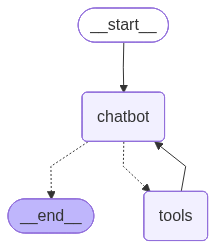

In [14]:
from langgraph.prebuilt import ToolNode, tools_condition

# LangGraph가 제공하는 공식 ToolNode를 사용한다.
tool_node = ToolNode(tools)

workflow = StateGraph(State)

# 각 노드를 그래프에 등록한다.
workflow.add_node("chatbot", chatbot)
workflow.add_node("tools", tool_node)

# 그래프 시작 지점은 chatbot 노드이다.
workflow.add_edge(START, "chatbot")

# 도구 실행 결과를 LLM이 다시 읽고 최종 답변을 만들 수 있도록 chatbot으로 되돌린다.
workflow.add_edge("tools", "chatbot")

# chatbot의 결과에 tool_calls가 있으면 tools로 없으면 END로 이동한다.
workflow.add_conditional_edges(
    'chatbot',
    tools_condition,
    {'tools': 'tools', END : END}
)

prebuilt_graph = workflow.compile()
prebuilt_graph

## 그래프 실행

In [15]:
from langchain_core.messages import HumanMessage

# 검색 도구를 사용할 가능성이 높은 질문
user_input = '오늘 기준 LangGraph에서 ToolNode가 어떤 역할을 하는지 검색해서 설명해줘.'
initial_state = {'messages' : [HumanMessage(content=user_input)]}

final_state = prebuilt_graph.invoke(initial_state)
final_state

{'messages': [HumanMessage(content='오늘 기준 LangGraph에서 ToolNode가 어떤 역할을 하는지 검색해서 설명해줘.', additional_kwargs={}, response_metadata={}, id='c5351044-e8f5-4039-92f0-ce10a80cd590'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 29, 'prompt_tokens': 1206, 'total_tokens': 1235, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4.1-mini-2025-04-14', 'system_fingerprint': 'fp_1382f6fe5a', 'id': 'chatcmpl-DggtymWTuj6MkiUISiMyLP4h9yrRQ', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019e38a9-052c-72f0-b084-bf2544b11a87-0', tool_calls=[{'name': 'tavily_search', 'args': {'query': 'LangGraph ToolNode 역할', 'time_range': 'day', 'topic': 'general'}, 'id': 'call_jqCPmI69eRaigEoOK8YZYkoi', 'typ

In [16]:
# 도구 요청이 필요하지 않을 것 같은 일반 질문
user_input = '인공지능이 사람의 삶을 어떻게 변화시킬까?'
initial_state = {'messages' : [HumanMessage(content=user_input)]}

final_state = prebuilt_graph.invoke(initial_state)
final_state

{'messages': [HumanMessage(content='인공지능이 사람의 삶을 어떻게 변화시킬까?', additional_kwargs={}, response_metadata={}, id='c16ff06f-2c3e-44ea-8ced-9559a78fc3dd'),
  AIMessage(content='인공지능(AI)은 사람의 삶을 여러 방면에서 크게 변화시키고 있습니다. 주요 변화를 몇 가지로 정리하면 다음과 같습니다:\n\n1. 효율성과 생산성 향상\n- 자동화: 반복적이고 단순한 업무를 AI가 대신 수행하여 사람은 더 창의적이고 전략적인 업무에 집중할 수 있습니다.\n- 데이터 분석: 방대한 데이터를 빠르고 정확하게 분석해 의사결정을 돕습니다.\n\n2. 개인화된 서비스 제공\n- 맞춤형 추천: 쇼핑, 엔터테인먼트, 교육 등에서 개인의 취향과 필요에 맞는 맞춤형 콘텐츠와 상품을 추천합니다.\n- 건강 관리: 개인 건강 데이터를 분석해 맞춤형 건강 관리와 질병 예방을 지원합니다.\n\n3. 새로운 직업과 산업 창출\n- AI 관련 개발자, 데이터 과학자 등 새로운 직업군이 등장하며 AI 기반 신산업이 성장하고 있습니다.\n- 기존 산업도 AI를 도입하여 혁신과 경쟁력을 강화하고 있습니다.\n\n4. 일상생활의 편리성 증대\n- 음성 인식 비서, 스마트 홈, 자율 주행 등으로 일상 생활이 더욱 편리하고 안전해집니다.\n- 언어 장벽 해소, 접근성 향상 등 다양한 사회적 문제도 개선됩니다.\n\n5. 윤리적, 사회적 도전과 변화\n- 개인정보 보호, AI 결정의 투명성, 편향성 문제 등 새로운 윤리적 이슈가 대두되고 있습니다.\n- 노동시장 변화와 사회적 불평등 문제에 대한 대응도 필요합니다.\n\n요약하면, AI는 삶의 질을 높이고 다양한 기회를 창출하지만 동시에 새로운 도전과 책임도 요구하는 중요한 기술입니다. 앞으로 기술 발전과 함께 사람과 AI의 조화로운 협력 방안이 더욱 중요해질 것입니다.', additional_kwargs={'refusal': N